In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load the data
df = pd.read_csv('Leads.csv')

In [3]:
# 1. See the size of the data
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.\n")

Dataset has 9240 rows and 37 columns.



In [4]:
# 2. Check for missing values
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

In [5]:
# Combine into a summary table
missing_df = pd.DataFrame({
    'Missing Count' : missing_counts,
    'Percentage (%)' : missing_pct
}).sort_values(by='Percentage (%)', ascending=False)

print("Top 10 Columns with Missing Values:")
print(missing_df.head(15))

Top 10 Columns with Missing Values:
                                               Missing Count  Percentage (%)
Lead Quality                                            4767       51.590909
Asymmetrique Profile Index                              4218       45.649351
Asymmetrique Activity Score                             4218       45.649351
Asymmetrique Activity Index                             4218       45.649351
Asymmetrique Profile Score                              4218       45.649351
Tags                                                    3353       36.287879
What matters most to you in choosing a course           2709       29.318182
Lead Profile                                            2709       29.318182
What is your current occupation                         2690       29.112554
Country                                                 2461       26.634199
How did you hear about X Education                      2207       23.885281
Specialization                          

# Missing Columns Handling

The Asymmetrique Columns (~45.6% missing): These are proprietary lead scores generated by an external agency. Because almost half the data is missing and we don't know the exact logic behind how the agency calculated these scores, keeping them might introduce bias. Decision: Drop them.

Lead Quality (~51.5% missing): This is based on the sales employee's intuition. It's highly missing because many leads are new and haven't been evaluated yet. However, "Not Sure" or missing is an important data point itself. Instead of dropping it, we can create a new category called "Not Specified".

Tags (~36.3% missing): These are tags assigned by sales sub-teams. Like Lead Quality, we can impute the missing values with "Not Specified".

In [6]:
# 1. Drop the Asymmetrique columns completely
columns_to_drop = [
    'Asymmetrique Profile Index', 
    'Asymmetrique Activity Score', 
    'Asymmetrique Activity Index', 
    'Asymmetrique Profile Score'
    ]

df = df.drop(columns=columns_to_drop)

In [7]:
# 2. Impute high-missing categorical columns with a new category
columns_to_impute = ['Lead Quality', 'Tags', 'Lead Profile', 'What is your current occupation']
for col in columns_to_impute:
    df[col] = df[col].fillna('Not Specified')

In [8]:
# 3. Check the remaining missing values to see our progress
remaining_missing = df.isnull().sum().sort_values(ascending=False)
print("Remaining missing values (Top 5):")
print(remaining_missing.head(5))

Remaining missing values (Top 5):
What matters most to you in choosing a course    2709
Country                                          2461
How did you hear about X Education               2207
Specialization                                   1438
City                                             1420
dtype: int64


In [9]:
# List of the remaining missing columns we see on your screen
more_columns_to_impute = [
    'What matters most to you in choosing a course',
    'Country',
    'How did you hear about X Education',
    'Specialization',
    'City'
]

In [10]:
# 1. Fill the actual blank spaces with 'Not Specified'
for col in more_columns_to_impute:
    df[col] = df[col].fillna('Not Specified')

In [11]:
# 2. Replace the literal word 'Select' with 'Not Specified' 
# (Because 'Select' means the user skipped the dropdown menu)
df = df.replace('Select', 'Not Specified')

In [12]:
# 3. Re-run the check to see if we hit 0 missing values!
print("Remaining missing values across the whole dataset:")
print(df.isnull().sum().sort_values(ascending=False).head(5))

Remaining missing values across the whole dataset:
TotalVisits             137
Page Views Per Visit    137
Last Activity           103
Lead Source              36
Prospect ID               0
dtype: int64


In [13]:
# 1. Handle Numeric Columns (Fill with Median)
df['TotalVisits'] = df['TotalVisits'].fillna(df['TotalVisits'].median())
df['Page Views Per Visit'] = df['Page Views Per Visit'].fillna(df['Page Views Per Visit'].median())

In [14]:
# 2. Handle remaining tiny Categorical Columns (Fill with Mode/Most Frequent)
df['Last Activity'] = df['Last Activity'].fillna(df['Last Activity'].mode()[0])
df['Lead Source'] = df['Lead Source'].fillna(df['Lead Source'].mode()[0])

In [15]:
# 3. The Ultimate Check - Let's see if the entire dataset is 100% clean!
print("Total missing values left in the entire DataFrame:")
print(df.isnull().sum().sum())

Total missing values left in the entire DataFrame:
0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# 1. Calculate conversion rates
conversion_counts = df['Converted'].value_counts()
conversion_rate = df['Converted'].mean() * 100

print(f"Total Leads: {len(df)}")
print(f"Did Not Convert (0): {conversion_counts[0]}")
print(f"Converted (1): {conversion_counts[1]}")
print(f"Overall Conversion Rate: {conversion_rate:.2f}%")

Total Leads: 9240
Did Not Convert (0): 5679
Converted (1): 3561
Overall Conversion Rate: 38.54%


C:\Users\Harsh\AppData\Local\Temp\ipykernel_7588\3294391918.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Converted', data=df, palette='Set2')


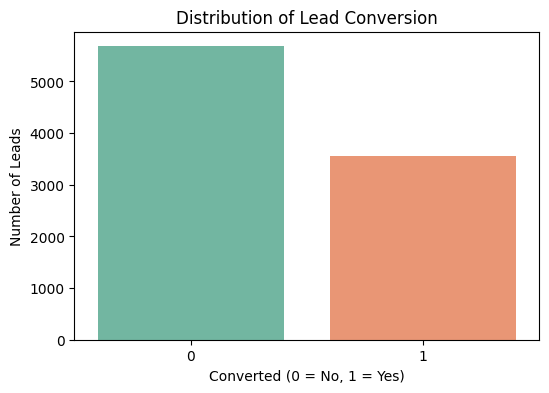

In [21]:
# 2. Plot it so it looks good in your portfolio
plt.figure(figsize=(6,4))
sns.countplot(x='Converted', data=df, palette='Set2')
plt.title('Distribution of Lead Conversion')
plt.xlabel('Converted (0 = No, 1 = Yes)')
plt.ylabel('Number of Leads')
plt.show()

C:\Users\Harsh\AppData\Local\Temp\ipykernel_7588\2960937537.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Converted', y='Total Time Spent on Website', data=df, palette='viridis')


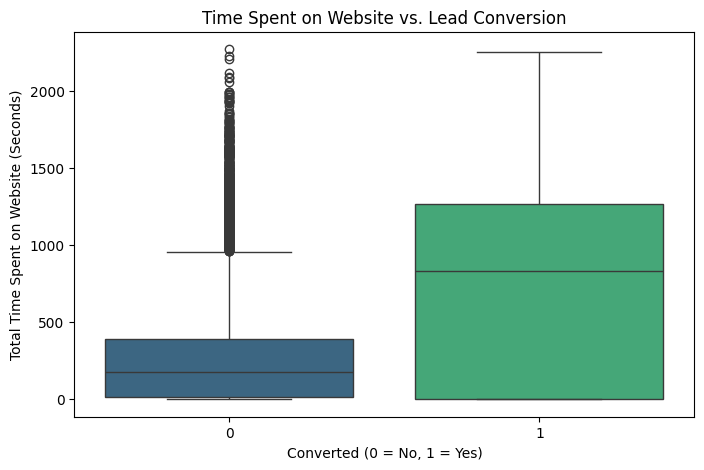

In [24]:
# Compare the average time spent on the website for converted vs non-converted leads
plt.figure(figsize=(8, 5))
sns.boxplot(x='Converted', y='Total Time Spent on Website', data=df, palette='viridis')
plt.title('Time Spent on Website vs. Lead Conversion')
plt.xlabel('Converted (0 = No, 1 = Yes)')
plt.ylabel('Total Time Spent on Website (Seconds)')
plt.show()

In [25]:
# Print the exact averages
avg_time = df.groupby('Converted')['Total Time Spent on Website'].mean()
print("Average Time Spent on Website:")
print(f"Leads who DID NOT convert: {avg_time[0]:.2f} seconds")
print(f"Leads who DID convert: {avg_time[1]:.2f} seconds")

Average Time Spent on Website:
Leads who DID NOT convert: 330.40 seconds
Leads who DID convert: 738.55 seconds
